In [1]:
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import xarray as xr

from acspype import ACSDev, ACSTSCor
import acspype.processing as acsproc

In [2]:
data_fp = '../../dev_tools/test_files/TEST_SHIMADA_202405.nc'
dev_fp = '../../dev_tools/test_files/ACS-00412_2023-05-10.dev'

In [3]:
acs = xr.open_dataset(data_fp)
acs = acs.drop_vars([v for v in acs.data_vars if '_dark' in v], errors = 'ignore')
dev = ACSDev(dev_fp)

In [4]:
acs['internal_temperature'] = acsproc.compute_internal_temperature(counts = acs.raw_internal_temperature)
acs = acs.drop_vars(['raw_internal_temperature'], errors = 'ignore')

In [5]:
acs['a_uncorr'] = acsproc.compute_uncorrected(signal_counts=acs.a_signal,
                                                   reference_counts=acs.a_reference,
                                                   path_length = dev.path_length)

acs['c_uncorr'] = acsproc.compute_uncorrected(signal_counts = acs.c_signal,
                                                   reference_counts = acs.c_reference,
                                                   path_length = dev.path_length)

acs['a_m_discontinuity'] = acsproc.compute_measured(uncorrected = acs.a_uncorr,
                                                    internal_temperature = acs.internal_temperature,
                                                    offset = dev.a_offset,
                                                    func_delta_t = dev.func_a_delta_t)

acs['c_m_discontinuity'] = acsproc.compute_measured(uncorrected = acs.c_uncorr,
                                                    internal_temperature = acs.internal_temperature,
                                                    offset = dev.c_offset,
                                                    func_delta_t=dev.func_c_delta_t)

discontinuity_index = acsproc.find_discontinuity_index(a_wavelength = acs.a_wavelength,
                                                       c_wavelength = acs.c_wavelength,
                                                       min_wvl = 500, max_wvl = 650)

acs['a_m'], acs['a_discontinuity_offset'] = acsproc.discontinuity_correction(measured = acs.a_m_discontinuity,
                                                                             discontinuity_index=discontinuity_index,
                                                                             wavelength_dim='a_wavelength')

acs['c_m'], acs['c_discontinuity_offset'] = acsproc.discontinuity_correction(measured = acs.c_m_discontinuity,
                                                                             discontinuity_index=discontinuity_index,
                                                                             wavelength_dim='c_wavelength')

In [6]:
tscor = ACSTSCor().to_xarray()  ## Load the TSCor coefficients as an xarray dataset.

# TSCor coeffs for absorption.
psi_t_a = tscor.psi_t.sel(wavelength=acs.a_wavelength)
psi_s_a = tscor.psi_s_a.sel(wavelength=acs.a_wavelength)

# TSCor coeffs for attenuation.
psi_t_c = tscor.psi_t.sel(wavelength=acs.c_wavelength)
psi_s_c = tscor.psi_s_c.sel(wavelength=acs.c_wavelength)

In [7]:
tcal = dev.tcal  # The reference temperature value in the device file.

acs['a_mts'] = acsproc.ts_correction(measured = acs.a_m,
                                     temperature = acs.sea_water_temperature,
                                     salinity = acs.sea_water_practical_salinity,
                                     psi_temperature = psi_t_a,
                                     psi_salinity= psi_s_a,
                                     tcal = tcal)

acs['c_mts'] = acsproc.ts_correction(measured = acs.c_m,
                                     temperature = acs.sea_water_temperature,
                                     salinity = acs.sea_water_practical_salinity,
                                     psi_temperature= psi_t_c,
                                     psi_salinity = psi_s_c,
                                     tcal = tcal)

In [8]:
acs['a_mts'] = acsproc.zero_shift_correction(acs.a_mts)
acs['c_mts'] = acsproc.zero_shift_correction(acs.c_mts)

In [9]:
acsi = acsproc.interpolate_common_wavelengths(acs)

In [10]:
ref_a = acsi.a_mts.sel(wavelength = 715, method = 'nearest')
ref_c = acsi.c_mts.sel(wavelength = 715, method = 'nearest')

In [11]:
acsi['a_mts_baseline'] = acsproc.baseline_scattering_correction(acsi.a_mts, reference_a = ref_a)
acsi['a_mts_baseline'] = acsproc.zero_shift_correction(acsi.a_mts_baseline)

acsi['a_mts_proportional'] = acsproc.proportional_scattering_correction(acsi.a_mts, acsi.c_mts,
                                                                       reference_a = ref_a, reference_c = ref_c)
acsi['a_mts_proportional'] = acsproc.zero_shift_correction(acsi.a_mts_proportional)

acsi['a_mts_fixed1'] = acsproc.fixed_scattering_correction(acsi.a_mts, acsi.c_mts, epsilon = 0.14)
acsi['a_mts_fixed2'] = acsproc.fixed_scattering_correction(acsi.a_mts, acsi.c_mts, epsilon = 0.18)

In [12]:
acsi['c_mts'] = acsi['c_mts'].rolling({'wavelength': 20}, center = True, min_periods = 1).median()

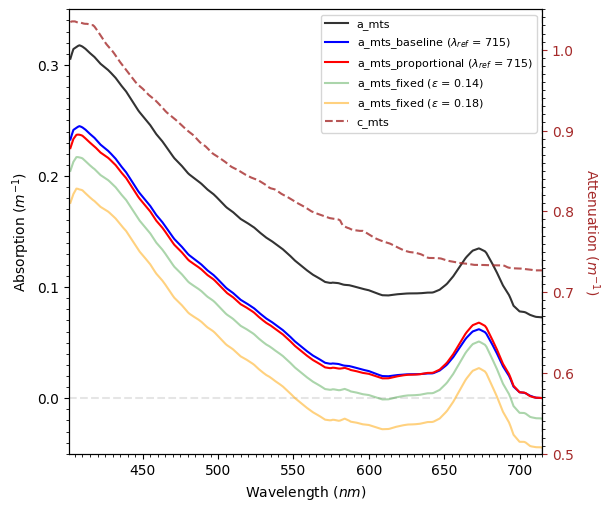

In [13]:
s0 = acsi.sel(time = datetime(2024,6,4,3,31,34,289202), method = 'nearest')

fig, ax = plt.subplots(1,1, figsize = (6,5), constrained_layout = True)

ax.plot(s0.wavelength, s0.a_mts, color = 'black', label = "a_mts", zorder = 1, alpha = 0.8)
ax.plot(s0.wavelength, s0.a_mts_baseline, color = 'blue', label = r'a_mts_baseline (${\lambda}_{ref}$ = 715)', zorder = 3)
ax.plot(s0.wavelength, s0.a_mts_proportional, color = 'red', label = r'a_mts_proportional (${\lambda}_{ref}$ = 715)', zorder = 3)
ax.plot(s0.wavelength, s0.a_mts_fixed1, color = 'green', label = r'a_mts_fixed ($\epsilon$ = 0.14)', alpha = 0.33, zorder = 2)
ax.plot(s0.wavelength, s0.a_mts_fixed2, color = 'orange', label = r'a_mts_fixed ($\epsilon$ = 0.18)', alpha = 0.5, zorder = 2)
ax.axhline(0, color = 'black', linestyle = '--', zorder = 0, alpha = 0.1)
ax.axvline(715, color = 'black', linestyle = '--', zorder = 0, alpha = 0.1)
ax.plot([],[],color = 'brown', linestyle = '--', label = 'c_mts', zorder = 1, alpha = 0.8)
ax.legend(loc = 'upper right', fontsize = 8)
ax.set_ylim(-0.05,0.35)
ax.set_ylabel(r'Absorption ($m^{-1}$)')
ax.set_xlabel(r'Wavelength ($nm$)')

ax.xaxis.set_major_locator(MultipleLocator(50))
ax.xaxis.set_minor_locator(MultipleLocator(5))
ax.yaxis.set_major_locator(MultipleLocator(0.1))
ax.yaxis.set_minor_locator(MultipleLocator(0.01))

# Second Axis
axc = ax.twinx()
axc.plot(s0.wavelength, s0.c_mts, color = 'brown', linestyle = '--', label = 'c_mts', zorder = 1, alpha = 0.8)

axc.set_ylim(0.5,1.05)
axc.set_ylabel(r'Attenuation ($m^{-1}$)', rotation = 270, labelpad = 20)
axc.xaxis.set_major_locator(MultipleLocator(50))
axc.xaxis.set_minor_locator(MultipleLocator(5))
axc.yaxis.set_major_locator(MultipleLocator(0.1))
axc.yaxis.set_minor_locator(MultipleLocator(0.01))

axc.yaxis.label.set_color('brown')
axc.tick_params(axis='y', colors='brown')
ax.set_xlim(401,715)

plt.savefig('scattering_correction_example.jpg', dpi = 1200)